In [1]:
import torch
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, roc_curve, roc_auc_score
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader, Subset
from sklearn.model_selection import train_test_split
from google.colab import drive

# 1. Mount Drive (Essential for accessing your saved data.zip)
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
DATA_DIR = "/content/drive/MyDrive/Colab Notebooks/data/cds" 


In [3]:

file_path = f'{DATA_DIR}/bert_tokenized_tensors.pt'
print(f"Loading tensors from {file_path}...")

# weights_only=True fixes the PyTorch security warning
data = torch.load(file_path, weights_only=True) 

input_ids = data['input_ids']
attention_masks = data['attention_masks']
labels = data['labels']

print(f"Input IDs shape: {input_ids.shape}")
print(f"Attention Masks shape: {attention_masks.shape}")
print(f"Labels shape: {labels.shape}")



Loading tensors from /content/drive/MyDrive/Colab Notebooks/data/cds/bert_tokenized_tensors.pt...
Input IDs shape: torch.Size([51843, 256])
Attention Masks shape: torch.Size([51843, 256])
Labels shape: torch.Size([51843])


In [4]:
# 2. Define the Dataset Wrapper
class PostsDataset(Dataset):
    def __init__(self, input_ids, attention_masks, labels):
        self.input_ids = input_ids
        self.attention_masks = attention_masks
        self.labels = labels

    def __getitem__(self, idx):
        return {
            'input_ids': self.input_ids[idx],
            'attention_masks': self.attention_masks[idx],
            'labels': self.labels[idx]
        }
    
    def __len__(self):
        return len(self.labels)

# Instantiate the full dataset
full_dataset = PostsDataset(input_ids, attention_masks, labels)



In [5]:
print("\nPerforming 70/15/15 dataset split...")

# Step A: Split into 70% Train and 30% Temporary (Validation + Test)
# We use stratify=labels.numpy() to ensure the 0/1 ratio remains perfectly balanced in all splits
train_idx, temp_idx = train_test_split(
    range(len(full_dataset)), 
    test_size=0.30, 
    stratify=labels.numpy(), 
    random_state=42
)

# Step B: Split the 30% Temporary subset evenly in half to get 15% Validation and 15% Test
val_idx, test_idx = train_test_split(
    temp_idx, 
    test_size=0.50, 
    stratify=[labels[i].item() for i in temp_idx], 
    random_state=42
)

# 4. Create PyTorch Subsets
train_dataset = Subset(full_dataset, train_idx)
val_dataset = Subset(full_dataset, val_idx)
test_dataset = Subset(full_dataset, test_idx)

print(f"Total dataset size: {len(full_dataset)}")
print(f"Train size: {len(train_dataset)} (70%)")
print(f"Val size:   {len(val_dataset)} (15%)")
print(f"Test size:  {len(test_dataset)} (15%)")

# 5. Create DataLoaders
# Batch size of 16 is standard for BERT, reduce to 8 if you run out of GPU memory
batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("\nDataLoaders successfully created and ready for training!")


Performing 70/15/15 dataset split...
Total dataset size: 51843
Train size: 36290 (70%)
Val size:   7776 (15%)
Test size:  7777 (15%)

DataLoaders successfully created and ready for training!


In [6]:
# load BERT model

from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [7]:
print(model)

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [9]:
# freeze the pretrained layers
for param in model.bert.parameters():
    param.requires_grad = False

# keep only the classification head trainable
for param in model.classifier.parameters():
    param.requires_grad = True

print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")

Trainable parameters: 1538


In [ ]:
# training function

from tqdm import tqdm

def train(model, dataloader, optimizer, device):
    model.train()
    total_loss = 0
    total_preds = []
    total_labels = []

    for step, batch in enumerate(tqdm(dataloader, desc="Training")):
        # 1. MOVE TO GPU: Send the current batch of 32 rows to the GPU
        input_ids = batch["input_ids"].to(device)
        attention_masks = batch["attention_masks"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()

        # 2. RUN ON GPU: The model processes the batch
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_masks,
            labels=labels
        )

        loss = outputs.loss
        logits = outputs.logits
        total_loss += loss.item() # .item() safely extracts the number from the GPU

        # 3. RUN ON GPU: Calculate gradients and update weights
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        # 4. GET PREDICTIONS ON GPU: Find the highest probability class (0 or 1)
        preds = torch.argmax(logits, dim=1)

        # 5. MOVE BACK TO CPU: 
        # .detach()  -> Unhooks the data from the GPU's gradient graph
        # .cpu()     -> Moves it from GPU VRAM back to standard computer RAM
        # .numpy()   -> Converts it from a PyTorch tensor to a standard Python/NumPy list
        total_preds.extend(preds.detach().cpu().numpy())
        total_labels.extend(labels.detach().cpu().numpy())

    # 6. RUN ON CPU: Scikit-learn calculates the final score using the CPU arrays
    avg_loss = total_loss / len(dataloader)
    accuracy = accuracy_score(total_labels, total_preds)
    f1score = f1_score(total_labels, total_preds)

    return avg_loss, accuracy, f1score



In [11]:
def evaluate(model, dataloader, device):
    model.eval()
    total_loss = 0
    total_preds = []
    total_labels = []

    with torch.no_grad(): # Disables gradient tracking entirely to save GPU memory
        for batch in tqdm(dataloader, desc="Evaluating"):
            # 1. MOVE TO GPU
            input_ids = batch["input_ids"].to(device)
            attention_masks = batch["attention_masks"].to(device)
            labels = batch["labels"].to(device)

            # 2. RUN ON GPU
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_masks,
                labels=labels
            )

            loss = outputs.loss
            logits = outputs.logits
            total_loss += loss.item()

            # 3. GET PREDICTIONS ON GPU
            preds = torch.argmax(logits, dim=1)

            # 4. MOVE BACK TO CPU for safe storage and metric calculation
            total_preds.extend(preds.detach().cpu().numpy())
            total_labels.extend(labels.detach().cpu().numpy())

    # 5. RUN ON CPU
    avg_loss = total_loss / len(dataloader)
    accuracy = accuracy_score(total_labels, total_preds)
    f1score = f1_score(total_labels, total_preds)

    return avg_loss, accuracy, f1score

In [12]:
import os

class EarlyStopping:
    def __init__(self, patience, mode='max', delta=0, save_dir="checkpoints", filename="best_model.pt"):
        self.patience = patience
        self.mode = mode 
        self.delta = delta
        
        # Create the directory if it doesn't exist
        self.save_dir = save_dir
        if not os.path.exists(self.save_dir):
            os.makedirs(self.save_dir)
            print(f"Created directory: {self.save_dir}")
            
        self.path = os.path.join(self.save_dir, filename)
        self.counter = 0
        self.best_score = None
        self.early_stop = False

    def __call__(self, val_score, model):
        if self.best_score is None:
            self.best_score = val_score
            self.save_checkpoint(model)
            return

        if self.mode == 'max':
            if val_score < self.best_score + self.delta:
                self.counter += 1
                print(f"EarlyStopping counter: {self.counter}/{self.patience}")
                if self.counter >= self.patience:
                    self.early_stop = True
            else:
                self.best_score = val_score
                self.save_checkpoint(model)
                self.counter = 0
                
        elif self.mode == 'min':
            if val_score > self.best_score - self.delta:
                self.counter += 1
                print(f"EarlyStopping counter: {self.counter}/{self.patience}")
                if self.counter >= self.patience:
                    self.early_stop = True
            else:
                self.best_score = val_score
                self.save_checkpoint(model)
                self.counter = 0

    def save_checkpoint(self, model):
        # Saves the model state_dict to the specified directory/file
        print(f"Validation improved. Saving best model to {self.path}...")
        torch.save(model.state_dict(), self.path)

In [ ]:
def training_loop(model, train_loader, val_loader, optimizer, early_stopping, num_epochs, device):
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    train_f1s, val_f1s = [], []

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")

        train_loss, train_acc, train_f1 = train(
            model, train_loader, optimizer, device
        )

        val_loss, val_acc, val_f1 = evaluate(
            model, val_loader, device
        )

        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
        print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)
        train_f1s.append(train_f1)
        val_f1s.append(val_f1)

        early_stopping(val_acc, model)

        if early_stopping.early_stop:
            print("Early stopping triggered. Halting training.")
            break
            
    # Reload the best weights from the directory before finishing
    print(f"\nTraining Complete. Loading best weights from '{early_stopping.path}'...")
    model.load_state_dict(torch.load(early_stopping.path, weights_only=True))
    
    return train_losses, val_losses, train_accs, val_accs, train_f1s, val_f1s

In [14]:
import os


CHECKPOINT_DIR = f"{DATA_DIR}/bert_checkpoints"
if not os.path.exists(CHECKPOINT_DIR):
    os.makedirs(CHECKPOINT_DIR)
    print(f"Created directory: {CHECKPOINT_DIR}")

# ==========================================
# PHASE 1: Train Only the Classification Head
# ==========================================
# Freeze all BERT parameters
for param in model.bert.parameters():
    param.requires_grad = False

# Keep only the final classifier layer trainable
for param in model.classifier.parameters():
    param.requires_grad = True

# Monitor validation accuracy (higher is better)
early_stopping = EarlyStopping(patience=3, mode='max', save_dir=CHECKPOINT_DIR, filename="phase1_head.pt")
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)

# Run Phase 1 (1 Epoch)
train_losses_1, val_losses_1, train_accs_1, val_accs_1, train_f1s_1, val_f1s_1 = training_loop(
    model, train_loader, val_loader, optimizer, early_stopping, 1, device
)

# ==========================================
# PHASE 2: Unfreeze Last 2 BERT Layers
# ==========================================
for param in model.bert.encoder.layer[-2:].parameters():
    param.requires_grad = True

# New EarlyStopping instance for this phase to track improvements properly
early_stopping = EarlyStopping(patience=3, mode='max', save_dir=CHECKPOINT_DIR, filename="phase2_unfrozen_2.pt")
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5) # Lower learning rate

# Run Phase 2 (3 Epochs)
train_losses_2, val_losses_2, train_accs_2, val_accs_2, train_f1s_2, val_f1s_2 = training_loop(
    model, train_loader, val_loader, optimizer, early_stopping, 3, device
)

# ==========================================
# PHASE 3: Unfreeze Last 4 BERT Layers
# ==========================================
for param in model.bert.encoder.layer[-4:-2].parameters():
    param.requires_grad = True
    
early_stopping = EarlyStopping(patience=3, mode='max', save_dir=CHECKPOINT_DIR, filename="phase3_unfrozen_4.pt")
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-6) # Even lower learning rate

# Run Phase 3 (3 Epochs)
train_losses_3, val_losses_3, train_accs_3, val_accs_3, train_f1s_3, val_f1s_3 = training_loop(
    model, train_loader, val_loader, optimizer, early_stopping, 3, device
)


Epoch 1/1


Evaluating: 100%|██████████| 243/243 [00:53<00:00,  4.55it/s]


Train Loss: 0.4105 | Train Acc: 0.8440
Val Loss:   0.3698 | Val Acc:   0.8481
Validation improved. Saving best model to /content/drive/MyDrive/Colab Notebooks/data/cds/bert_checkpoints/phase1_head.pt...

Training Complete. Loading best weights from '/content/drive/MyDrive/Colab Notebooks/data/cds/bert_checkpoints/phase1_head.pt'...

Epoch 1/3


Evaluating: 100%|██████████| 243/243 [00:53<00:00,  4.55it/s]


Train Loss: 0.0641 | Train Acc: 0.9777
Val Loss:   0.0280 | Val Acc:   0.9909
Validation improved. Saving best model to /content/drive/MyDrive/Colab Notebooks/data/cds/bert_checkpoints/phase2_unfrozen_2.pt...

Epoch 2/3


...

Train Loss: 0.0172 | Train Acc: 0.9948
Val Loss:   0.0199 | Val Acc:   0.9945
Validation improved. Saving best model to /content/drive/MyDrive/Colab Notebooks/data/cds/bert_checkpoints/phase3_unfrozen_4.pt...

Epoch 2/3


Evaluating: 100%|██████████| 243/243 [00:53<00:00,  4.55it/s]


Train Loss: 0.0114 | Train Acc: 0.9967
Val Loss:   0.0178 | Val Acc:   0.9956
Validation improved. Saving best model to /content/drive/MyDrive/Colab Notebooks/data/cds/bert_checkpoints/phase3_unfrozen_4.pt...

Epoch 3/3


Evaluating: 100%|██████████| 243/243 [00:53<00:00,  4.54it/s]


Train Loss: 0.0069 | Train Acc: 0.9978
Val Loss:   0.0244 | Val Acc:   0.9937
EarlyStopping counter: 1/3

Training Complete. Loading best weights from '/content/drive/MyDrive/Colab Notebooks/data/cds/bert_checkpoints/phase3_unfrozen_4.pt'...


In [ ]:
# model.eval()

# correct_predictions = 0
# total_predictions = 0

# # Disable gradient calculation for validation (saves memory and prevents learning)
# with torch.no_grad():
#     for batch in val_dataloader:
#         b_input_ids = batch[0].to(device)
#         b_input_mask = batch[1].to(device)
#         b_labels = batch[2].to(device)

#         outputs = model(
#             b_input_ids, 
#             attention_mask=b_input_mask
#         )
        
#         # Get the highest probability prediction
#         logits = outputs.logits
#         predictions = torch.argmax(logits, dim=1)
        
#         # Compare to actual labels
#         correct_predictions += (predictions == b_labels).sum().item()
#         total_predictions += b_labels.size(0)

# true_accuracy = correct_predictions / total_predictions
# print(f"True Validation Accuracy: {true_accuracy * 100:.2f}%")

NameError: name 'val_dataloader' is not defined

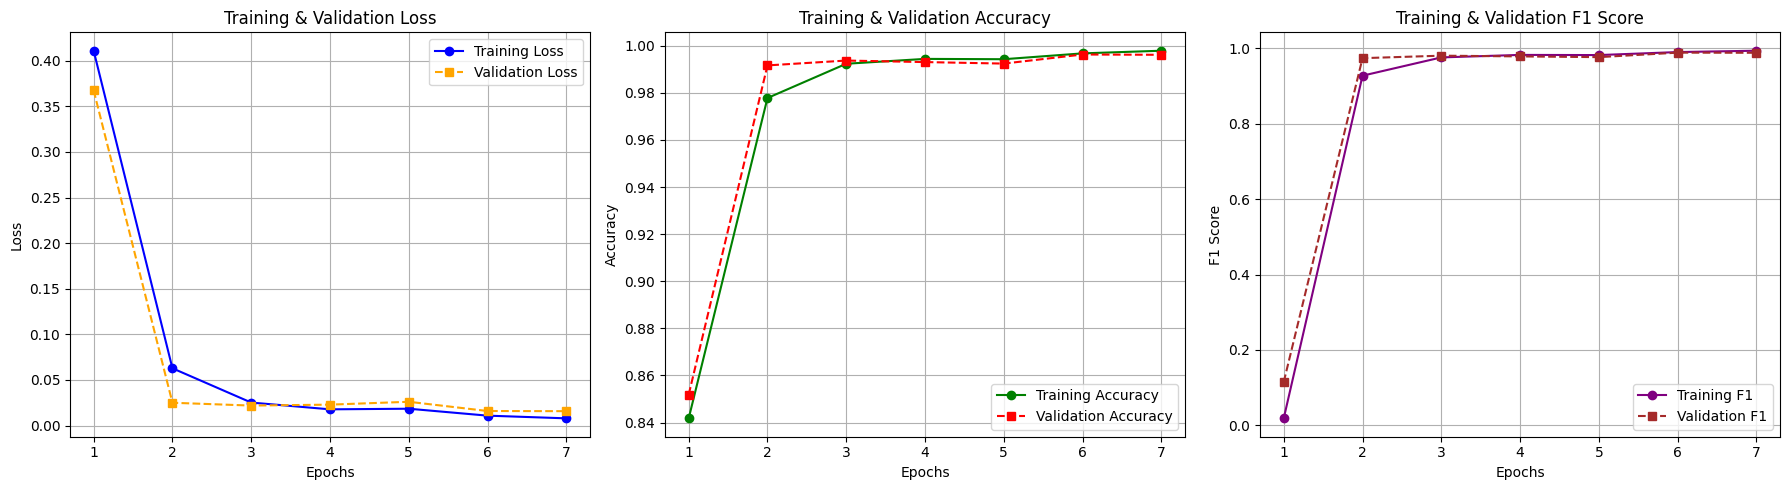

In [ ]:
# plot graphs

total_train_losses = train_losses_1 + train_losses_2 + train_losses_3
total_train_accs = train_accs_1 + train_accs_2 + train_accs_3
total_train_f1s = train_f1s_1 + train_f1s_2 + train_f1s_3
total_val_losses = val_losses_1 + val_losses_2 + val_losses_3
total_val_accs = val_accs_1 + val_accs_2 + val_accs_3
total_val_f1s = val_f1s_1 + val_f1s_2 + val_f1s_3
iters = list(range(1, len(total_train_losses) + 1))

# 3. Create the figure with 3 subplots
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# --- Plot 1: Loss ---
ax[0].plot(iters, total_train_losses, marker='o', color='blue', label='Training Loss')
ax[0].plot(iters, total_val_losses, marker='s', color='orange', linestyle='--', label='Validation Loss')
ax[0].set_title('Training & Validation Loss')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].grid(True)
ax[0].legend()

# --- Plot 2: Accuracy ---
ax[1].plot(iters, total_train_accs, marker='o', color='green', label='Training Accuracy')
ax[1].plot(iters, total_val_accs, marker='s', color='red', linestyle='--', label='Validation Accuracy')
ax[1].set_title('Training & Validation Accuracy')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Accuracy')
ax[1].grid(True)
ax[1].legend()

# --- Plot 3: F1 Score ---
ax[2].plot(iters, total_train_f1s, marker='o', color='purple', label='Training F1')
ax[2].plot(iters, total_val_f1s, marker='s', color='brown', linestyle='--', label='Validation F1')
ax[2].set_title('Training & Validation F1 Score')
ax[2].set_xlabel('Epochs')
ax[2].set_ylabel('F1 Score')
ax[2].grid(True)
ax[2].legend()

plt.tight_layout()


In [ ]:
def evaluate_on_testing_set(y_test, y_pred):
  # Calculate AUC
  print("AUC is: ", roc_auc_score(y_test, y_pred))

  # print out recall and precision
  print(classification_report(y_test, y_pred))

  # print out confusion matrix
  print("Confusion Matrix: \n", confusion_matrix(y_test, y_pred))

  # # calculate points for ROC curve
  fpr, tpr, thresholds = roc_curve(y_test, y_pred)

  # Plot ROC curve
  plt.plot(fpr, tpr, label='ROC curve (area = %0.3f)' % roc_auc_score(y_test, y_pred))
  plt.plot([0, 1], [0, 1], 'k--')  # random predictions curve
  plt.xlim([0.0, 1.0])
  plt.ylim([0.0, 1.0])
  plt.xlabel('False Positive Rate or (1 - Specifity)')
  plt.ylabel('True Positive Rate or (Sensitivity)')
  plt.title('Receiver Operating Characteristic')

In [ ]:
# testing

model.eval()

test_loss = 0
test_preds = []
test_labels = []

with torch.no_grad():

    for batch in tqdm(test_loader):

        input_ids = batch["input_ids"].to(device)
        attention_masks = batch["attention_masks"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_masks,
            labels=labels
        )

        loss = outputs.loss
        logits = outputs.logits

        test_loss += loss.item()

        preds = torch.argmax(logits, dim=1)

        test_preds.extend(preds.detach().cpu().numpy())
        test_labels.extend(labels.detach().cpu().numpy())

100%|██████████| 244/244 [00:52<00:00,  4.61it/s]


Test Loss: 5.597911827724602
AUC is:  0.9881364204313455
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6559
           1       0.98      0.98      0.98      1218

    accuracy                           0.99      7777
   macro avg       0.99      0.99      0.99      7777
weighted avg       0.99      0.99      0.99      7777

Confusion Matrix: 
 [[6538   21]
 [  25 1193]]


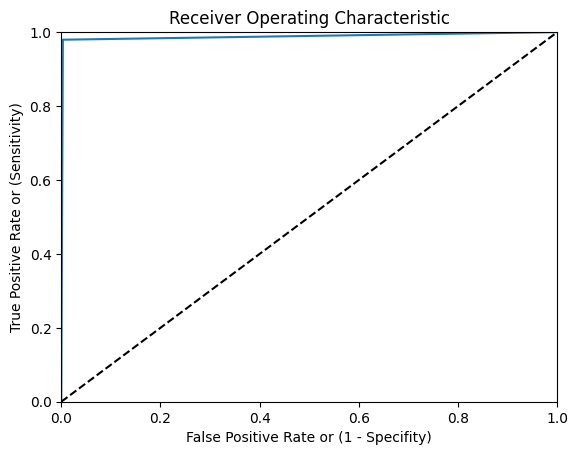

In [ ]:
# testing metrics

print("Test Loss:", test_loss)
evaluate_on_testing_set(test_labels, test_preds)

In [ ]:


fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Combine all training histories
all_train_losses = train_losses_1 + train_losses_2 + train_losses_3
all_val_losses = val_losses_1 + val_losses_2 + val_losses_3
all_train_accs = train_accs_1 + train_accs_2 + train_accs_3
all_val_accs = val_accs_1 + val_accs_2 + val_accs_3
all_train_f1s = train_f1s_1 + train_f1s_2 + train_f1s_3
all_val_f1s = val_f1s_1 + val_f1s_2 + val_f1s_3

epochs = range(1, len(all_train_losses) + 1)

# Mark phase boundaries
phase1_end = len(train_losses_1)
phase2_end = phase1_end + len(train_losses_2)

# Plot 1: Loss
axes[0, 0].plot(epochs, all_train_losses, 'b-', label='Training Loss', linewidth=2)
axes[0, 0].plot(epochs, all_val_losses, 'r-', label='Validation Loss', linewidth=2)
axes[0, 0].axvline(x=phase1_end + 0.5, color='gray', linestyle='--', alpha=0.7, label='Phase Boundaries')
axes[0, 0].axvline(x=phase2_end + 0.5, color='gray', linestyle='--', alpha=0.7)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Training and Validation Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Accuracy (main plot)
axes[0, 1].plot(epochs, all_train_accs, 'b-', label='Training Accuracy', linewidth=2)
axes[0, 1].plot(epochs, all_val_accs, 'r-', label='Validation Accuracy', linewidth=2)
axes[0, 1].axvline(x=phase1_end + 0.5, color='gray', linestyle='--', alpha=0.7, label='Phase Boundaries')
axes[0, 1].axvline(x=phase2_end + 0.5, color='gray', linestyle='--', alpha=0.7)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('Training and Validation Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Add accuracy values on the plot
for i, (train_acc, val_acc) in enumerate(zip(all_train_accs, all_val_accs)):
    if i % 2 == 0:  # Annotate every other point to avoid clutter
        axes[0, 1].annotate(f'{train_acc:.3f}', (epochs[i], train_acc), 
                          textcoords="offset points", xytext=(0,10), ha='center', fontsize=8)
        axes[0, 1].annotate(f'{val_acc:.3f}', (epochs[i], val_acc), 
                          textcoords="offset points", xytext=(0,-15), ha='center', fontsize=8)

# Plot 3: F1 Score
axes[1, 0].plot(epochs, all_train_f1s, 'b-', label='Training F1', linewidth=2)
axes[1, 0].plot(epochs, all_val_f1s, 'r-', label='Validation F1', linewidth=2)
axes[1, 0].axvline(x=phase1_end + 0.5, color='gray', linestyle='--', alpha=0.7, label='Phase Boundaries')
axes[1, 0].axvline(x=phase2_end + 0.5, color='gray', linestyle='--', alpha=0.7)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('F1 Score')
axes[1, 0].set_title('Training and Validation F1 Score')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Final Test Results - Confusion Matrix Heatmap
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(test_labels, test_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1, 1])
axes[1, 1].set_xlabel('Predicted')
axes[1, 1].set_ylabel('Actual')
axes[1, 1].set_title(f'Confusion Matrix - Test Set\nAccuracy: {accuracy_score(test_labels, test_preds):.4f}')

plt.tight_layout()
plt.show()

# Additional visualization: Per-phase accuracy comparison
fig, ax = plt.subplots(figsize=(10, 6))

# Prepare data for phase comparison
phases = ['Phase 1\n(Head Only)', 'Phase 2\n(Last 2 Layers)', 'Phase 3\n(Last 4 Layers)']
best_train_accs = [max(train_accs_1), max(train_accs_2), max(train_accs_3)]
best_val_accs = [max(val_accs_1), max(val_accs_2), max(val_accs_3)]
final_test_acc = accuracy_score(test_labels, test_preds)

x = np.arange(len(phases))
width = 0.25

bars1 = ax.bar(x - width, best_train_accs, width, label='Best Training Accuracy', color='lightblue')
bars2 = ax.bar(x, best_val_accs, width, label='Best Validation Accuracy', color='lightgreen')
bars3 = ax.bar(x + width, [final_test_acc] * len(phases), width, label='Final Test Accuracy', color='orange', alpha=0.7)

ax.set_xlabel('Training Phase')
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy Comparison Across Training Phases')
ax.set_xticks(x)
ax.set_xticklabels(phases)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.4f}',
                   xy=(bar.get_x() + bar.get_width() / 2, height),
                   xytext=(0, 3),
                   textcoords="offset points",
                   ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "="*50)
print("TRAINING SUMMARY")
print("="*50)
print(f"\nPhase 1 (Classification Head Only):")
print(f"  Best Training Accuracy: {max(train_accs_1):.4f}")
print(f"  Best Validation Accuracy: {max(val_accs_1):.4f}")
print(f"  Final Training Accuracy: {train_accs_1[-1]:.4f}")
print(f"  Final Validation Accuracy: {val_accs_1[-1]:.4f}")

print(f"\nPhase 2 (Unfroze Last 2 Layers):")
print(f"  Best Training Accuracy: {max(train_accs_2):.4f}")
print(f"  Best Validation Accuracy: {max(val_accs_2):.4f}")
print(f"  Final Training Accuracy: {train_accs_2[-1]:.4f}")
print(f"  Final Validation Accuracy: {val_accs_2[-1]:.4f}")

print(f"\nPhase 3 (Unfroze Last 4 Layers):")
print(f"  Best Training Accuracy: {max(train_accs_3):.4f}")
print(f"  Best Validation Accuracy: {max(val_accs_3):.4f}")
print(f"  Final Training Accuracy: {train_accs_3[-1]:.4f}")
print(f"  Final Validation Accuracy: {val_accs_3[-1]:.4f}")

print(f"\nFINAL TEST RESULTS:")
print(f"  Test Accuracy: {accuracy_score(test_labels, test_preds):.4f}")
print(f"  Test F1 Score: {f1_score(test_labels, test_preds):.4f}")
print(f"  Test AUC: {roc_auc_score(test_labels, test_preds):.4f}")